# 4 Neural Networks

Our goal is to make 4 neural nets:
1. We have already made the first, out encoder which is an MLP that takes us to 512 ChemNet space
2. An MLP that will take spectra and output toxicity. We also want to make an RF that will do the same
3. An MLP that will take ChemNet embeddings and output toxicity, again we already have a RF that does this, which limited success for unknown chemical compounds.
4. The most complicated, a condiotnal encoder that will intake Spectra and output 516 space, which one hot encoded EPA levels as additinal conditions. This has many further considerations since it will need to peicewise loss function. 


Another condsideration as we start getting these NNs up and running is what problem we want to tackle, multi-class or binary classification and regression are the main two. Additionally we have been using EPA LD50 toxicity levels but the Georgia Institute of Technology indicates that "A substance is considered extremely toxic if it has an LD50 of less than 5 mgs/kg of animal body weight." This could be another bench mark of binary classification, classifying only "extremely toxic" chemicals with LD50 socres below 5. The primary problem that this poses is that there are just VERY few chemicals that fit this description, making major balance issues, compounding the existing problem, as even with an EPA split we see relatively few chemcals of even EPA level 1.

However EPA levels are revealing as "it is Highly toxic if it has an LD50 of between 5 and 50 mg/kg of animal body weight to a human, this would be about a teaspoon." And 50 is the EPA level 1 benchmark, so could also be used as a benchmark for binary classification, however the balance issues would still persist, and they would be inconsistent across groups. 

# General: Functions, Data Upload etc.

## Imports and Globally Used Functions

In [134]:
# Package imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor



In [135]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [136]:
# Binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [137]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [138]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"

In [139]:
# Add the 'Response' and 'log_response' columns THIS IS A UNIVERSAL FUNCTION
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

In [140]:
# Add the 'Response' column using the SMILES as an identifier
def add_response_column_to_spectra(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    return spectra_df

## Initial Data upload and processing

In [141]:
# The 5/30 dataset with rat based toxicity data and groups
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# This will give us the subsets with all of the relevant information
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 


# Now since I have saved files of the binned specrtra I can simply call those
df3_QQpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQneg_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv")
df3_LTQOpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
df3_QTOFpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")


(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


In [142]:
# Counts of extrmemly toxic chemicals
num_extremely_toxic = (df3_QQpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_QQneg['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_QTOFpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_LTQOpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

Number of SMILES with Response < 10: 15
Number of SMILES with Response < 10: 6
Number of SMILES with Response < 10: 18
Number of SMILES with Response < 10: 8


# Spectra --> ChemNet Encoder

### Functions

In [143]:
# This is our default function, the one we use to prep the data for the encoder that takes us from spectra to ChemNet encodings 
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

### Architecture

In [253]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 5

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_encoder(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss) and loss2 (toxicity loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training

In [254]:
# Training and validation dataset split 
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

# Save under correct names
train_data_df3_QQpos = train_data
test_data_df3_QQpos = test_data
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 681)
(579, 681)


In [255]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQpos = pd.concat([train_data_df3_QQpos, test_data_df3_QQpos], ignore_index=True)
super_testing_df3_QQpos = combined_df3_QQpos[combined_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQpos = train_data_df3_QQpos[~train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQpos = test_data_df3_QQpos[~test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQpos.shape)
print("After removal, test shape:", test_data_df3_QQpos.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any left in train?", any(train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (564, 681)
After removal, test shape: (538, 681)
Super testing set shape: (86, 681)
Any left in train? False
Any left in test? False


In [220]:
# # Verification of the number of training and testing SMILES present
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QQpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QQpos = train_data_df3_QQpos[train_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QQpos = test_data_df3_QQpos[test_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())

In [256]:
# Ensure we match the data correctly:
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos
val_data = test_data
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()


In [257]:
train_data_df3_QQpos_copy.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,671,672,673,674,675,676,677,678,679,index
12,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12
13,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13
14,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14
15,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
16,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16


In [258]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQpos = train_model_encoder(
    model=encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQpos = x_val
x_train_df3_QQpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21468.0 MB
  Memory Used: 2748.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.08659973657793468
   Validation loss: 0.017491761595010757
Epoch [2/500]
   Training loss: 0.07367795126305686
   Validation loss: 0.014973756857216358
Epoch [3/500]
   Training loss: 0.06662949671347936
   Validation loss: 0.014291337691247463
Epoch [4/500]
   Training loss: 0.06284535883201493
   Validation loss: 0.014063470996916294
Epoch [5/500]
   Training loss: 0.06073350873258379
   Validation loss: 0.013567275367677212
Epoch [6/500]
   Training loss: 0.05894848994082875
   Validation loss: 0.013505379669368267
Epoch [7/500]
   Training loss: 0.05683641177084711
   Validation loss: 0.012709559872746468
Epoch [8/500]
   Training loss: 0.054423704743385315
   Validation loss: 0.011847342364490032
Epoch [9/500]
   Training 

### Testing

In [151]:
# This is simply excecuting a test of the encoder, we do this process again down below when we want the encoder ouputs to be MLP inputs.
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)



### Training QTOFpos

In [259]:
# Training and validation dataset split 
df3_QTOFpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QTOFpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QTOFpos_copy = train_data.copy()
test_data_df3_QTOFpos_copy = test_data.copy()

# Save under correct names
train_data_df3_QTOFpos = train_data
test_data_df3_QTOFpos = test_data
# Load val_data
val_data = test_data

(330, 2003)
(308, 2003)


In [260]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QTOFpos = pd.concat([train_data_df3_QTOFpos, test_data_df3_QTOFpos], ignore_index=True)
super_testing_df3_QTOFpos = combined_df3_QTOFpos[combined_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QTOFpos = train_data_df3_QTOFpos[~train_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QTOFpos = test_data_df3_QTOFpos[~test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QTOFpos.shape)
print("After removal, test shape:", test_data_df3_QTOFpos.shape)
print("Super testing set shape:", super_testing_df3_QTOFpos.shape)
print("Any left in train?", any(train_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (298, 2003)
After removal, test shape: (279, 2003)
Super testing set shape: (61, 2003)
Any left in train? False
Any left in test? False


In [261]:
# Ensure we match the data correctly:
train_data = train_data_df3_QTOFpos
test_data = test_data_df3_QTOFpos
val_data = test_data
train_data_df3_QTOFpos_copy = train_data.copy()
test_data_df3_QTOFpos_copy = test_data.copy()


In [262]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QTOFpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QTOFpos = train_model_encoder(
    model=encoder_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QTOFpos = x_val
x_train_df3_QTOFpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21468.0 MB
  Memory Used: 2748.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.082273830473423
   Validation loss: 0.028606349602341652
Epoch [2/500]
   Training loss: 0.0697280377149582
   Validation loss: 0.025148117914795876
Epoch [3/500]
   Training loss: 0.06263119876384735
   Validation loss: 0.022854486480355263
Epoch [4/500]
   Training loss: 0.0576687753200531
   Validation loss: 0.02115193009376526
Epoch [5/500]
   Training loss: 0.05464589074254036
   Validation loss: 0.020209426060318947
Epoch [6/500]
   Training loss: 0.0514952152967453
   Validation loss: 0.018549662083387375
Epoch [7/500]
   Training loss: 0.048374686390161514
   Validation loss: 0.01766788214445114
Epoch [8/500]
   Training loss: 0.044929804652929305
   Validation loss: 0.017057446762919426
Epoch [9/500]
   Training loss: 

# Spectra --> Toxicity MLP and Random Forest

### Processing

In [152]:
# Add the 'Response' column using the SMILES as an identifier
def add_response_column_to_spectra(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra') # Add response (needed to add EPA)

# Add EPA levels (one-hot encoded)
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    df["EPA_level"] = df[response_col].apply(assign_func)
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    #df.drop(columns=[response_col], inplace=True)
    return df

df3_QQpos_spectra_withEPA = add_epa_levels(df3_QQpos_spectra) # Add EPA, and then check to make sure
df3_QQpos_spectra_withEPA.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,676,677,678,679,Response,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0


In [153]:
# Super test removal, same as we had before with a even mix of EPA levels, though not all of these are in each group subset of the data.

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
super_testing_df3_QQpos = df3_QQpos_spectra_withEPA[df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()
super_testing_df3_QTOFpos = add_response_and_log_response(super_testing_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')

# Remove those SMILES from train and test sets
df3_QQpos_spectra_withEPA = df3_QQpos_spectra_withEPA[~df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, shape:", df3_QQpos_spectra_withEPA.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any leff?", any(df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)))


After removal, shape: (1218, 686)
Super testing set shape: (89, 686)
Any leff? False


In [154]:
super_testing_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,676,677,678,679,Response,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0


### Random Forest Classifier

In [155]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = df3_QQpos_spectra_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in df3_QQpos_spectra_withEPA.columns
    if col not in ['SMILES'] + [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1     24
EPA_level_2    239
EPA_level_3    720
EPA_level_4    235
dtype: int64


In [156]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = df3_QQpos_spectra_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = df3_QQpos_spectra_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

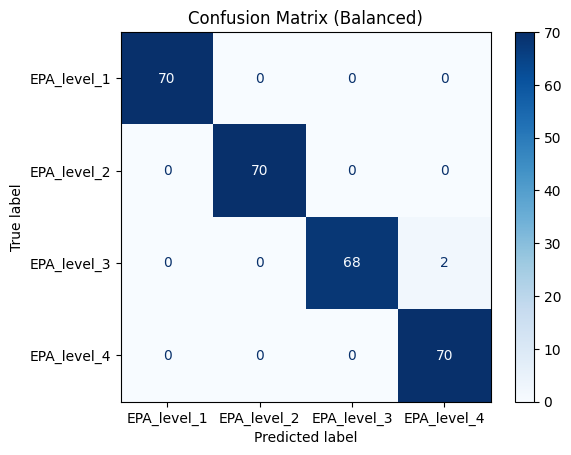

In [157]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Random Forest Classifier QTOFpos

In [158]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in df3_QTOFpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = df3_QTOFpos_spectra_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QTOFpos_withEPA:")
print(epa_counts)

# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in df3_QTOFpos_spectra_withEPA.columns
    if col not in ['SMILES'] + [col for col in df3_QTOFpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in df3_QTOFpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

EPA level counts in test_output_df3_QTOFpos_withEPA:
EPA_level_1     38
EPA_level_2    155
EPA_level_3    376
EPA_level_4    167
dtype: int64


In [159]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = df3_QTOFpos_spectra_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = df3_QTOFpos_spectra_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=5)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=5)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=5, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=5)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

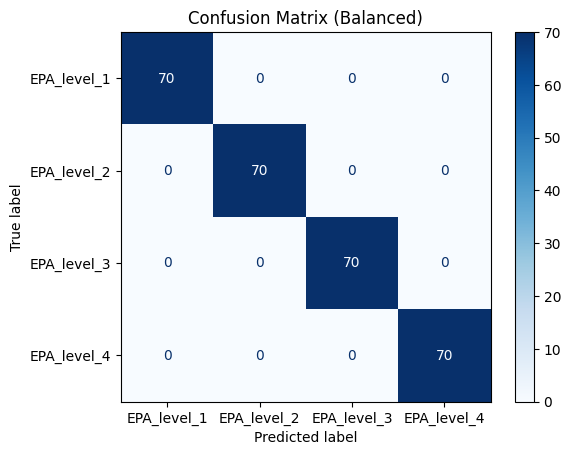

In [160]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Spectra to Toxicity MLP Architecture

In [161]:
#%%
# Everything below this line SHOULD be able to run without modification
class SpecToxMLP_Reg(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_MLP_spectra(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### MLP Training

In [194]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_data_df3_QQpos = train_data.copy()
test_data_df3_QQpos = test_data.copy()
val_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

In [182]:
# This isolates log response as the target varaible, not including embeddings at all.
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

In [195]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21666.0 MB
  Memory Used: 2550.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [196]:
#%%
SpecToxMLP_df3_QQpos = SpecToxMLP_Reg(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

batch_size = 128
epochs=1000
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 10


#%%
SpecToxMLP_model_df3_QQpos = train_model_MLP_spectra(
    model=SpecToxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

Epoch [1/1000]
   Training loss: 56.93692245483398
   Validation loss: 24.519535064697266
Epoch [2/1000]
   Training loss: 56.608045196533205
   Validation loss: 24.229963302612305
Epoch [3/1000]
   Training loss: 56.36103515625
   Validation loss: 24.986713409423828
Epoch [4/1000]
   Training loss: 55.175001525878905
   Validation loss: 23.341848373413086
Epoch [5/1000]
   Training loss: 52.22349395751953
   Validation loss: 21.484603881835938
Epoch [6/1000]
   Training loss: 43.876654052734374
   Validation loss: 15.64434814453125
Epoch [7/1000]
   Training loss: 25.82726287841797
   Validation loss: 6.5411376953125
Epoch [8/1000]
   Training loss: 12.436685752868652
   Validation loss: 10.125717163085938
Epoch [9/1000]
   Training loss: 12.315622901916504
   Validation loss: 5.226726055145264
Epoch [10/1000]
   Training loss: 9.05105962753296
   Validation loss: 4.655590057373047
Epoch [11/1000]
   Training loss: 8.548009300231934
   Validation loss: 4.305230140686035
Epoch [12/1000

### MLP Evaluation

In [198]:
# Spectra to tox MLP evaluation
SpecToxMLP_model_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = SpecToxMLP_model_df3_QQpos(x_val)  


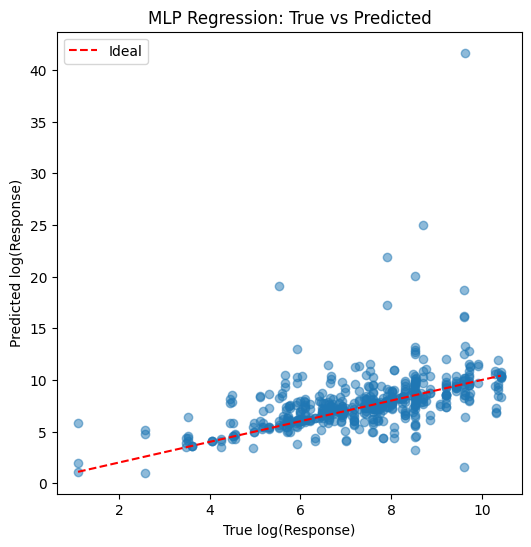

Mean Squared Error: 5.7535
R^2 Score: -1.2485


In [199]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QQpos.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

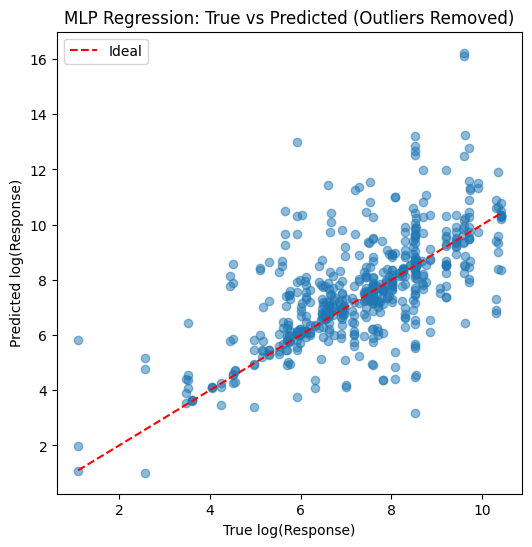

Mean Squared Error (filtered): 2.2574
R^2 Score (filtered): 0.1167


In [200]:
# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QQpos.cpu().numpy().flatten()

# Remove outliers: keep only points within 3 standard deviations of the residuals
residuals = y_true - y_pred
std_res = np.std(residuals)
mask = np.abs(residuals) < 3 * std_res
y_true_filtered = y_true[mask]
y_pred_filtered = y_pred[mask]

# Scatter plot: predicted vs true (filtered)
plt.figure(figsize=(6,6))
plt.scatter(y_true_filtered, y_pred_filtered, alpha=0.5)
plt.plot([y_true_filtered.min(), y_true_filtered.max()], [y_true_filtered.min(), y_true_filtered.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted (Outliers Removed)')
plt.legend()
plt.show()

# Quantitative metrics (filtered)
mse = mean_squared_error(y_true_filtered, y_pred_filtered)
r2 = r2_score(y_true_filtered, y_pred_filtered)
print(f"Mean Squared Error (filtered): {mse:.4f}")
print(f"R^2 Score (filtered): {r2:.4f}")

### Spectra MLP on super test set

In [168]:
super_testing_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,676,677,678,679,Response,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0


In [185]:
# Ensure model and tensor are on the same device
model_device = next(SpecToxMLP_model_df3_QQpos.parameters()).device
add_response_and_log_response(super_testing_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

# Debug: Check what the model expects vs what we have
print(f"Super test dataset shape: {super_testing_df3_QQpos.shape}")
#print(f"Super test columns: {super_testing_df3_QQpos.columns.tolist()}")

# Get the expected input size from the model
model_input_size = next(SpecToxMLP_model_df3_QQpos.parameters()).shape[1]
print(f"Model expects input size: {model_input_size}")

# Use only numeric columns, excluding EPA levels and other non-spectral data
numeric_cols = super_testing_df3_QQpos.select_dtypes(include=[np.number]).columns.tolist()
# Remove EPA level columns and response columns
spectral_cols = [col for col in numeric_cols if not col.startswith('EPA_level_') 
                 and col not in ['Response', 'log_response']]

print(f"Available spectral columns: {len(spectral_cols)}")
print(f"First few spectral columns: {spectral_cols[:5]}")
print(f"Last few spectral columns: {spectral_cols[-5:]}")

# Take only the number of features the model expects
if len(spectral_cols) >= model_input_size:
    selected_cols = spectral_cols[:model_input_size]
    print(f"Using first {model_input_size} spectral columns")
else:
    selected_cols = spectral_cols
    print(f"Warning: Only {len(spectral_cols)} spectral columns available, but model expects {model_input_size}")

spectra_super = super_testing_df3_QQpos[selected_cols]
log_tox_val_super = super_testing_df3_QQpos['log_response']

print(f"Final spectra_super shape: {spectra_super.shape}")

# Convert the spectra to a tensor 
x_val_super_test = torch.Tensor(spectra_super.values).to(model_device)

# Now we can run the model on the super test set
SpecToxMLP_model_df3_QQpos.eval()
with torch.no_grad():
    super_test_output = SpecToxMLP_model_df3_QQpos(x_val_super_test)

Super test dataset shape: (89, 686)
Model expects input size: 679
Available spectral columns: 679
First few spectral columns: ['1', '2', '3', '4', '5']
Last few spectral columns: ['675', '676', '677', '678', '679']
Using first 679 spectral columns
Final spectra_super shape: (89, 679)


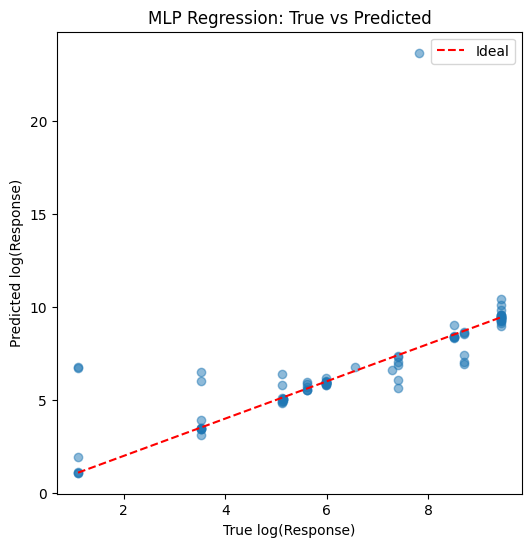

Mean Squared Error: 3.9083
R^2 Score: 0.3372


In [186]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = log_tox_val_super
y_pred = super_test_output.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


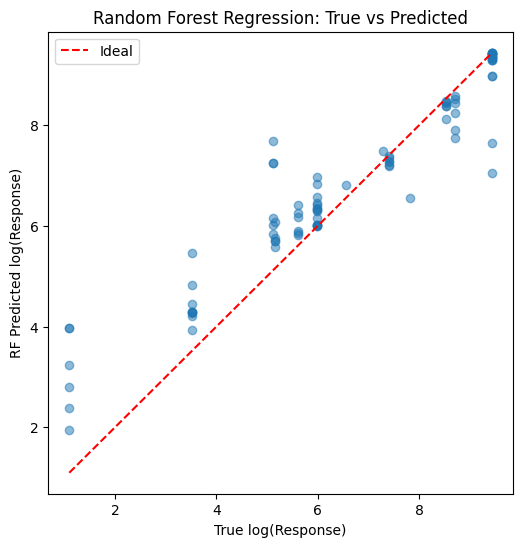

Random Forest Mean Squared Error: 0.8255
Random Forest R^2 Score: 0.8600


In [187]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg_QQpos = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_QQpos.fit(X_train, y_train)


# Predict on super test set
y_pred_rf = rf_reg_QQpos.predict(spectra_super)
y_true = log_tox_val_super

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_rf, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_true, y_pred_rf)
r2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Training QTOFpos

In [202]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QTOFpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")
df3_QTOFpos_spectra = add_response_and_log_response(df3_QTOFpos_spectra, df3_QTOFpos, smiles_col='SMILES_spectra')

# Generalize the syntax
dataset = df3_QTOFpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_data_df3_QTOFpos = train_data.copy()
test_data_df3_QTOFpos = test_data.copy()
val_data = test_data_df3_QTOFpos

# Make a copy
train_data_df3_QTOFpos_copy = train_data.copy()
test_data_df3_QTOFpos_copy = test_data.copy()

In [203]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

#%%
SpecToxMLP_df3_QTOFpos = SpecToxMLP_Reg(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

batch_size = 128
epochs=1000
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 10


#%%
SpecToxMLP_model_df3_QTOFpos = train_model_MLP_spectra(
    model=SpecToxMLP_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21664.0 MB
  Memory Used: 2552.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/1000]
   Training loss: 56.21170298258463
   Validation loss: 43.68644332885742
Epoch [2/1000]
   Training loss: 55.37815729777018
   Validation loss: 42.47105026245117
Epoch [3/1000]
   Training loss: 52.983890533447266
   Validation loss: 38.8706169128418
Epoch [4/1000]
   Training loss: 45.57880783081055
   Validation loss: 28.921977996826172
Epoch [5/1000]
   Training loss: 25.491642634073894
   Validation loss: 12.335029602050781
Epoch [6/1000]
   Training loss: 11.749361991882324
   Validation loss: 20.461854934692383
Epoch [7/1000]
   Training loss: 11.165666262308756
   Validation loss: 7.185306072235107
Epoch [8/1000]
   Training loss: 9.093900839487711
   Validation loss: 9.216358184814453
Epoch [9/1000]
   Training loss: 9.924155553181967
  

### MLP Evaluation QTOFpos

In [204]:
# Spectra to tox MLP evaluation
SpecToxMLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = SpecToxMLP_model_df3_QTOFpos(x_val)


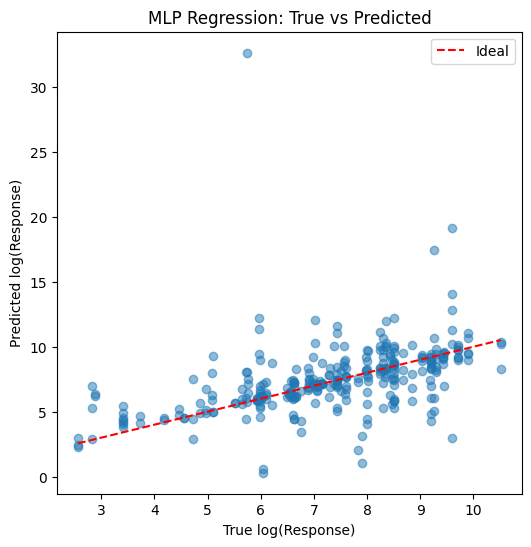

Mean Squared Error: 5.8904
R^2 Score: -1.0139


In [206]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QTOFpos.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

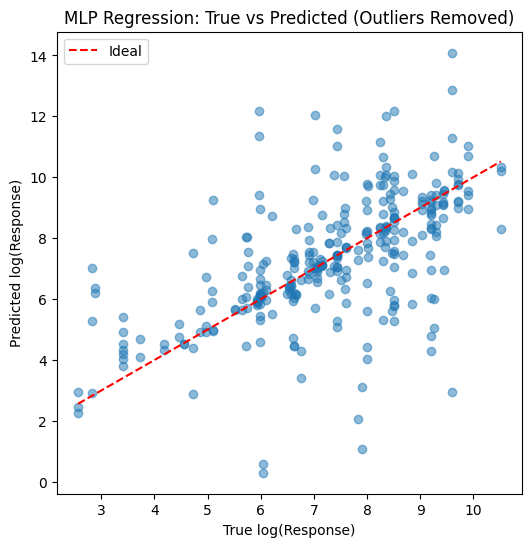

Mean Squared Error (filtered): 3.0548
R^2 Score (filtered): -0.0478


In [207]:
# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QTOFpos.cpu().numpy().flatten()

# Remove outliers: keep only points within 3 standard deviations of the residuals
residuals = y_true - y_pred
std_res = np.std(residuals)
mask = np.abs(residuals) < 3 * std_res
y_true_filtered = y_true[mask]
y_pred_filtered = y_pred[mask]

# Scatter plot: predicted vs true (filtered)
plt.figure(figsize=(6,6))
plt.scatter(y_true_filtered, y_pred_filtered, alpha=0.5)
plt.plot([y_true_filtered.min(), y_true_filtered.max()], [y_true_filtered.min(), y_true_filtered.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted (Outliers Removed)')
plt.legend()
plt.show()

# Quantitative metrics (filtered)
mse = mean_squared_error(y_true_filtered, y_pred_filtered)
r2 = r2_score(y_true_filtered, y_pred_filtered)
print(f"Mean Squared Error (filtered): {mse:.4f}")
print(f"R^2 Score (filtered): {r2:.4f}")

### Random forest regressor

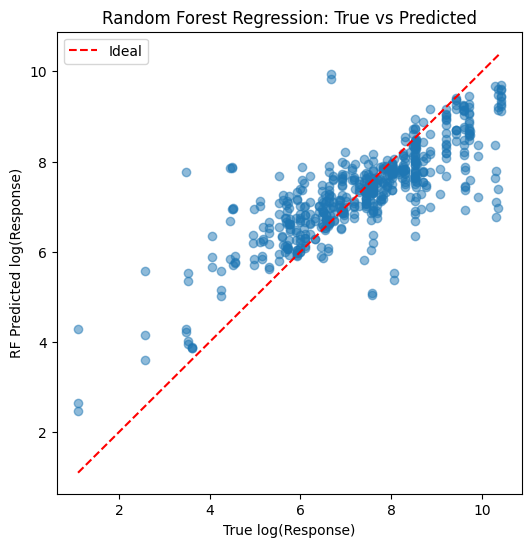

Random Forest Mean Squared Error: 0.9426
Random Forest R^2 Score: 0.6316


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_reg.predict(X_test)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### Specta MLP on QTOF super test set

In [190]:
# Ensure model and tensor are on the same device
model_device = next(SpecToxMLP_model_df3_QTOFpos.parameters()).device
add_response_and_log_response(super_testing_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')

# Debug: Check what the model expects vs what we have
print(f"Super test dataset shape: {super_testing_df3_QTOFpos.shape}")
#print(f"Super test columns: {super_testing_df3_QTOFpos.columns.tolist()}")

# Get the expected input size from the model
model_input_size = next(SpecToxMLP_model_df3_QTOFpos.parameters()).shape[1]
print(f"Model expects input size: {model_input_size}")

# Use only numeric columns, excluding EPA levels and other non-spectral data
numeric_cols = super_testing_df3_QTOFpos.select_dtypes(include=[np.number]).columns.tolist()
# Remove EPA level columns and response columns
spectral_cols = [col for col in numeric_cols if not col.startswith('EPA_level_') 
                 and col not in ['Response', 'log_response']]

print(f"Available spectral columns: {len(spectral_cols)}")
print(f"First few spectral columns: {spectral_cols[:5]}")
print(f"Last few spectral columns: {spectral_cols[-5:]}")

# Take only the number of features the model expects
if len(spectral_cols) >= model_input_size:
    selected_cols = spectral_cols[:model_input_size]
    print(f"Using first {model_input_size} spectral columns")
else:
    selected_cols = spectral_cols
    print(f"Warning: Only {len(spectral_cols)} spectral columns available, but model expects {model_input_size}")

spectra_super = super_testing_df3_QTOFpos[selected_cols]
log_tox_val_super = super_testing_df3_QTOFpos['log_response']

print(f"Final spectra_super shape: {spectra_super.shape}")

# Convert the spectra to a tensor 
x_val_super_test = torch.Tensor(spectra_super.values).to(model_device)

# Now we can run the model on the super test set
SpecToxMLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    super_test_output = SpecToxMLP_model_df3_QTOFpos(x_val_super_test)

Super test dataset shape: (61, 2004)
Model expects input size: 2001
Available spectral columns: 2001
First few spectral columns: ['1', '2', '3', '4', '5']
Last few spectral columns: ['1997', '1998', '1999', '2000', '2001']
Using first 2001 spectral columns
Final spectra_super shape: (61, 2001)


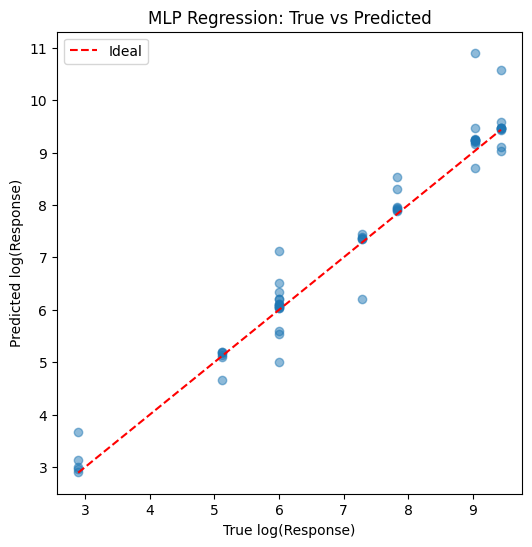

Mean Squared Error: 0.1920
R^2 Score: 0.9494


In [191]:
# Convert tensors to numpy arrays
y_true = log_tox_val_super
y_pred = super_test_output.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


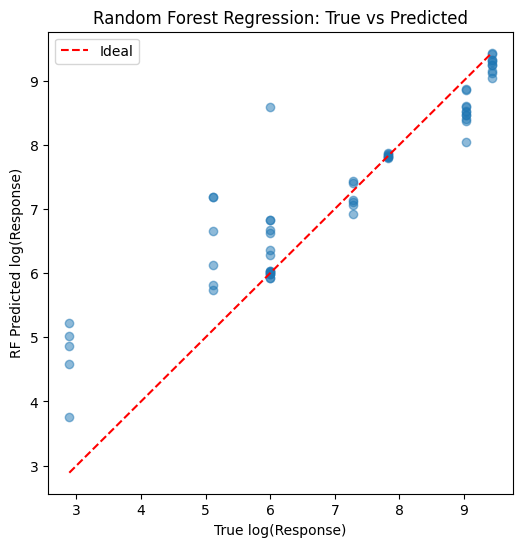

Random Forest Mean Squared Error: 0.7190
Random Forest R^2 Score: 0.8106


In [192]:
# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)


# Predict on super test set
y_pred_rf = rf_reg.predict(spectra_super)
y_true = log_tox_val_super

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_rf, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_true, y_pred_rf)
r2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### Random Forest Regressor QTOFpos

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_reg.predict(X_test)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

# ChemNet --> Toxicity MLP and Random Forest

### Processing to/of ChemNet Embeddings

In [263]:
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)



In [264]:
# Encoder excecution df3_QTOFpos
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_val_df3_QTOFpos)

with torch.no_grad():
    train_output_df3_QTOFpos = encoder_df3_QTOFpos(x_train_df3_QTOFpos)

# Encoder excecution df3_QTOFpos super testing
x_super_df3_QTOFpos = super_testing_df3_QTOFpos.iloc[:, 1:-1].values
x_super_tensor_df3_QTOFpos = torch.tensor(x_super_df3_QTOFpos, dtype=torch.float32).to(x_val_df3_QTOFpos.device)
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    super_test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_super_tensor_df3_QTOFpos)


In [265]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Ensure indices match before assignment
test_output_df3_QQpos = test_output_df3_QQpos.reset_index(drop=True)
test_data_df3_QQpos_copy = test_data_df3_QQpos_copy.reset_index(drop=True)
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos_copy['SMILES_spectra']

train_output_df3_QQpos = train_output_df3_QQpos.reset_index(drop=True)
train_data_df3_QQpos_copy = train_data_df3_QQpos_copy.reset_index(drop=True)
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos_copy['SMILES_spectra']


In [266]:
train_output_df3_QQpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 504,Embedding Float 505,Embedding Float 506,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra
0,-0.119324,0.000265,-0.008672,-0.117942,-0.045646,0.034593,-0.245727,-0.159126,-0.202101,-0.552177,...,-0.081181,0.124642,-0.000561,-0.500873,-0.145222,0.019526,-0.212970,0.055274,-0.351073,C=C(C)C1CC=C(C)CC1
1,-0.126408,0.003144,-0.020979,-0.119397,-0.040005,0.046381,-0.239105,-0.153328,-0.201954,-0.546104,...,-0.084143,0.126709,0.000167,-0.497880,-0.134451,0.029590,-0.216426,0.066860,-0.346256,C=C(C)C1CC=C(C)CC1
2,-0.112358,-0.000783,-0.028608,-0.107346,-0.042687,0.042736,-0.241495,-0.159162,-0.202619,-0.551633,...,-0.070148,0.117507,0.000315,-0.490252,-0.144937,0.024663,-0.214529,0.053876,-0.347588,C=C(C)C1CC=C(C)CC1
3,-0.128695,0.004447,-0.019469,-0.125970,-0.040381,0.022708,-0.231148,-0.157362,-0.205798,-0.551183,...,-0.066010,0.129969,0.000354,-0.490975,-0.147296,0.023195,-0.218999,0.052787,-0.358101,C=C(C)C1CC=C(C)CC1
4,-0.123006,-0.007201,-0.019366,-0.107517,-0.032305,0.036357,-0.247618,-0.151227,-0.208857,-0.549253,...,-0.088661,0.127064,0.002198,-0.494891,-0.135262,0.026075,-0.219192,0.061505,-0.347022,C=C(C)C1CC=C(C)CC1


In [267]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QTOFpos_np = test_output_df3_QTOFpos.cpu().numpy()
train_output_df3_QTOFpos_np = train_output_df3_QTOFpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QTOFpos = pd.DataFrame(test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QTOFpos_np.shape[1])])
train_output_df3_QTOFpos = pd.DataFrame(train_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QTOFpos_np.shape[1])])

# Ensure indices match before assignment
test_output_df3_QTOFpos = test_output_df3_QTOFpos.reset_index(drop=True)
test_data_df3_QTOFpos_copy = test_data_df3_QTOFpos_copy.reset_index(drop=True)
test_output_df3_QTOFpos['SMILES_spectra'] = test_data_df3_QTOFpos_copy['SMILES_spectra']

train_output_df3_QTOFpos = train_output_df3_QTOFpos.reset_index(drop=True)
train_data_df3_QTOFpos_copy = train_data_df3_QTOFpos_copy.reset_index(drop=True)
train_output_df3_QTOFpos['SMILES_spectra'] = train_data_df3_QTOFpos_copy['SMILES_spectra']

In [268]:
# Add the 'Response' values to the test and train outputs
# def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
#     """
#     Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
#     """
#     # Create mapping from SMILES to Response
#     smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
#     output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
#     return output_df

# Example usage for each output DataFrame:
test_output_df3_QQpos = add_response_and_log_response(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_and_log_response(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

test_output_df3_QTOFpos = add_response_and_log_response(test_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
train_output_df3_QTOFpos = add_response_and_log_response(train_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')


In [269]:
test_output_df3_QQpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 506,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response
0,-0.287056,0.048010,-0.002009,-0.309447,-0.004207,0.031330,0.055217,-0.189133,-0.124348,-0.134603,...,-0.055594,-0.000024,0.045889,-0.195248,0.110250,0.393848,-0.218863,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583
1,-0.256174,0.076341,0.039318,-0.334875,0.038667,0.074638,-0.149872,-0.233641,-0.223249,-0.397111,...,-0.091663,-0.144473,0.057127,-0.233207,0.117475,0.451994,-0.181721,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583
2,-0.054037,0.001164,0.047302,0.023913,-0.109126,0.181218,-0.287970,-0.145067,-0.246900,-0.247701,...,0.015879,-0.569041,-0.097025,-0.007806,-0.315036,0.135733,-0.374465,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583
3,-0.174247,-0.023714,0.149923,0.080544,-0.101604,0.337579,-0.193799,-0.000434,-0.160845,0.000466,...,0.005625,-0.334446,-0.068496,-0.037418,-0.275026,-0.034703,-0.190848,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583
4,-0.175481,0.028612,0.056491,-0.023221,-0.067437,0.135339,-0.311520,-0.104139,-0.074486,-0.408577,...,0.018544,-0.369866,-0.060721,0.115403,-0.062919,0.056111,-0.292503,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583


In [270]:
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    # Assign EPA levels
    df["EPA_level"] = df[response_col].apply(assign_func)
    # One-hot encode
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    # Convert boolean columns to int
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    # Remove the Response column
    #df.drop(columns=[response_col], inplace=True)
    return df

# Use it
test_output_df3_QQpos_withEPA = add_epa_levels(test_output_df3_QQpos)
train_output_df3_QQpos_withEPA = add_epa_levels(train_output_df3_QQpos)

test_output_df3_QTOFpos_withEPA = add_epa_levels(test_output_df3_QTOFpos)
train_output_df3_QTOFpos_withEPA = add_epa_levels(train_output_df3_QTOFpos)

In [271]:
test_output_df3_QQpos_withEPA.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,-0.287056,0.048010,-0.002009,-0.309447,-0.004207,0.031330,0.055217,-0.189133,-0.124348,-0.134603,...,0.110250,0.393848,-0.218863,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0,0,1,0
1,-0.256174,0.076341,0.039318,-0.334875,0.038667,0.074638,-0.149872,-0.233641,-0.223249,-0.397111,...,0.117475,0.451994,-0.181721,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0,0,1,0
2,-0.054037,0.001164,0.047302,0.023913,-0.109126,0.181218,-0.287970,-0.145067,-0.246900,-0.247701,...,-0.315036,0.135733,-0.374465,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0,0,1,0
3,-0.174247,-0.023714,0.149923,0.080544,-0.101604,0.337579,-0.193799,-0.000434,-0.160845,0.000466,...,-0.275026,-0.034703,-0.190848,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0,0,1,0
4,-0.175481,0.028612,0.056491,-0.023221,-0.067437,0.135339,-0.311520,-0.104139,-0.074486,-0.408577,...,-0.062919,0.056111,-0.292503,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0,0,1,0


In [272]:
# Process encoder outputs for super test set
# QQpos
super_test_output_df3_QQpos_np = super_test_output_df3_QQpos.cpu().numpy()
super_test_output_df3_QQpos_df = pd.DataFrame(
    super_test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QQpos_np.shape[1])]
)
super_test_output_df3_QQpos_df['SMILES_spectra'] = super_testing_df3_QQpos['SMILES_spectra'].values

# Add the 'Response' column using the original dataframes
super_test_output_df3_QQpos_df = add_response_and_log_response(super_test_output_df3_QQpos_df, df3_QQpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) and remove 'Response'
super_test_output_df3_QQpos_withEPA = add_epa_levels(super_test_output_df3_QQpos_df)


In [273]:
# QTOFpos
super_test_output_df3_QTOFpos_np = super_test_output_df3_QTOFpos.cpu().numpy()
super_test_output_df3_QTOFpos_df = pd.DataFrame(
    super_test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QTOFpos_np.shape[1])]
)
super_test_output_df3_QTOFpos_df['SMILES_spectra'] = super_testing_df3_QTOFpos['SMILES_spectra'].values

# Add the 'Response' column using the original dataframes
super_test_output_df3_QTOFpos_df = add_response_and_log_response(super_test_output_df3_QTOFpos_df, df3_QTOFpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) and remove 'Response'
super_test_output_df3_QTOFpos_withEPA = add_epa_levels(super_test_output_df3_QTOFpos_df)

### Random Forests

In [ ]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_output_df3_QQpos_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1      9
EPA_level_2    108
EPA_level_3    316
EPA_level_4    105
dtype: int64


In [ ]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [ ]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_output_df3_QQpos_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

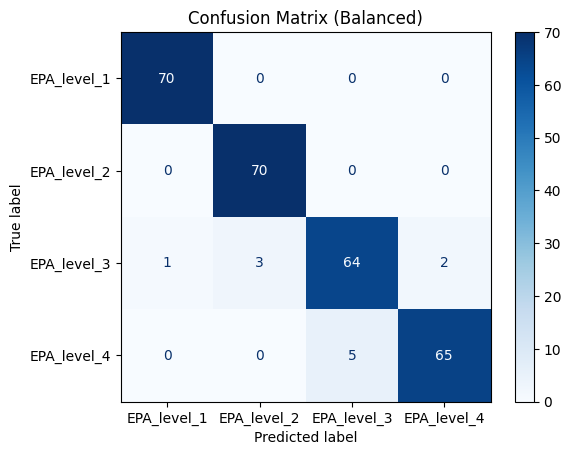

In [ ]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

In [274]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_output_df3_QTOFpos_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QTOFpos_withEPA:")
print(epa_counts)

EPA level counts in test_output_df3_QTOFpos_withEPA:
EPA_level_1     15
EPA_level_2     57
EPA_level_3    151
EPA_level_4     56
dtype: int64


In [275]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df3_QTOFpos_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [276]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_output_df3_QTOFpos_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df3_QTOFpos_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

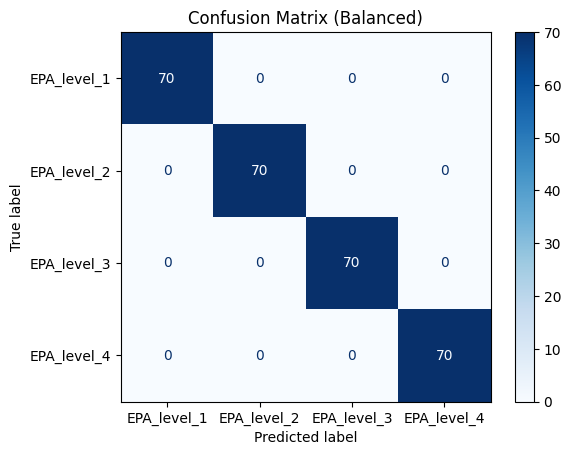

In [277]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Random Forest on super test set

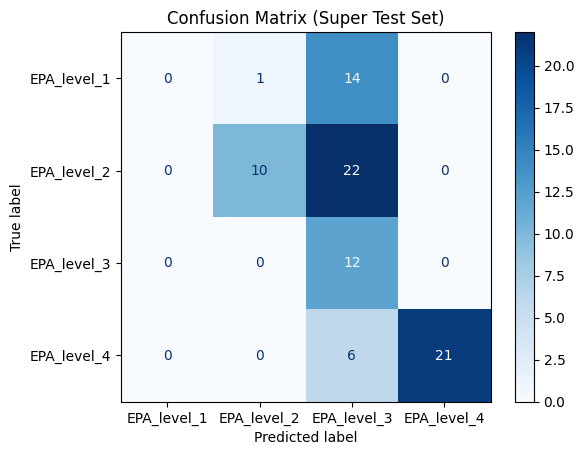

In [ ]:
# Define spectra columns for super test set (exclude non-numeric and EPA columns)
spectra_cols = [
    col for col in super_test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES_spectra'] + [col for col in super_test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
X_super = super_test_output_df3_QQpos_withEPA[spectra_cols].select_dtypes(include=[np.number])
y_super = super_test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Predict and plot confusion matrix
y_pred_super = rf_bal.predict(X_super)
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

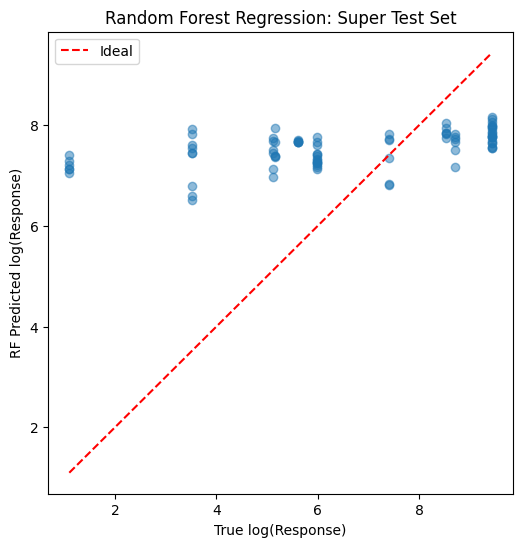

Super Test Set Mean Squared Error: 6.2163
Super Test Set R^2 Score: -0.0227


In [ ]:
# Now the same but with the random forest regressor
# Prepare X and y for train and test sets (ChemNet embeddings)
embedding_cols = [col for col in train_output_df3_QQpos.columns if col.startswith('Embedding Float')]
X_train_rf = train_output_df3_QQpos[embedding_cols].values
y_train_rf = train_output_df3_QQpos['log_response'].values

X_test_rf = test_output_df3_QQpos[embedding_cols].values
y_test_rf = test_output_df3_QQpos['log_response'].values

# Combine train and test for training
X_rf = np.vstack([X_train_rf, X_test_rf])
y_rf = np.concatenate([y_train_rf, y_test_rf])

# Prepare super test set
X_super_rf = super_test_output_df3_QQpos_withEPA[embedding_cols].values
y_super_rf = super_test_output_df3_QQpos_withEPA['log_response'].values

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)

# Predict on super test set
y_pred_super_rf = rf_reg.predict(X_super_rf)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_super_rf, y_pred_super_rf, alpha=0.5)
plt.plot([y_super_rf.min(), y_super_rf.max()], [y_super_rf.min(), y_super_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: Super Test Set')
plt.legend()
plt.show()

# Quantitative metrics
mse_super = mean_squared_error(y_super_rf, y_pred_super_rf)
r2_super = r2_score(y_super_rf, y_pred_super_rf)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

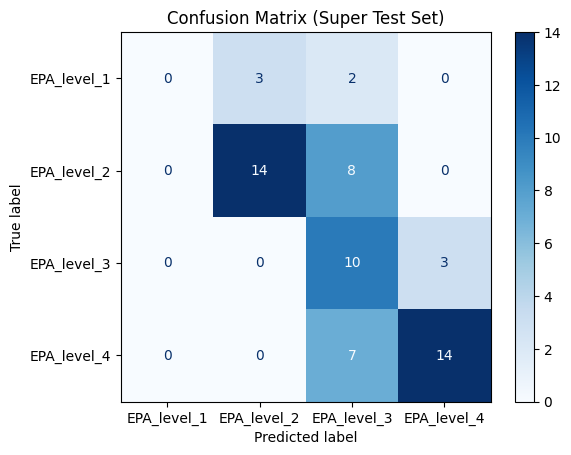

In [279]:
# Define spectra columns for super test set (exclude non-numeric and EPA columns)
spectra_cols = [
    col for col in super_test_output_df3_QTOFpos_withEPA.columns
    if col not in ['SMILES_spectra'] + [col for col in super_test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
X_super = super_test_output_df3_QTOFpos_withEPA[spectra_cols].select_dtypes(include=[np.number])
y_super = super_test_output_df3_QTOFpos_withEPA[epa_level_cols].idxmax(axis=1)

# Predict and plot confusion matrix
y_pred_super = rf_bal.predict(X_super)
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

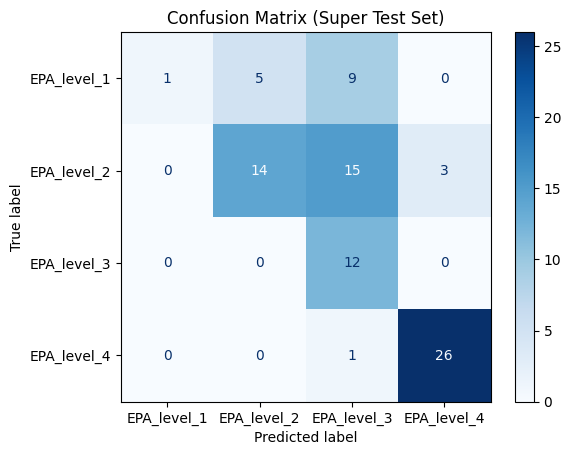

In [280]:
# Define spectra columns for super test set (exclude non-numeric and EPA columns)
spectra_cols = [
    col for col in super_test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES_spectra'] + [col for col in super_test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
X_super = super_test_output_df3_QQpos_withEPA[spectra_cols].select_dtypes(include=[np.number])
y_super = super_test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Predict and plot confusion matrix
y_pred_super = rf_bal.predict(X_super)
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

### MLP Data Processing

In [281]:
# Encoder excecution 
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos_copy['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos_copy['SMILES_spectra']

# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Add the response column
test_output_df3_QQpos = add_response_and_log_response(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_and_log_response(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')


# Add an index for bette integration into the MLP algorithm
test_output_df3_QQpos['index'] = test_output_df3_QQpos.index
train_output_df3_QQpos['index'] = train_output_df3_QQpos.index

# Save a copy
test_output_df3_QQpos_copy = test_output_df3_QQpos.copy()
train_output_df3_QQpos_copy = train_output_df3_QQpos.copy()

In [282]:
# Encoder excecution 
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_val_df3_QTOFpos)  

with torch.no_grad():
    train_output_df3_QTOFpos = encoder_df3_QTOFpos(x_train_df3_QTOFpos)

# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QTOFpos_np = test_output_df3_QTOFpos.cpu().numpy()
train_output_df3_QTOFpos_np = train_output_df3_QTOFpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QTOFpos = pd.DataFrame(test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QTOFpos_np.shape[1])])
train_output_df3_QTOFpos = pd.DataFrame(train_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QTOFpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QTOFpos['SMILES_spectra'] = test_data_df3_QTOFpos_copy['SMILES_spectra']
train_output_df3_QTOFpos['SMILES_spectra'] = train_data_df3_QTOFpos_copy['SMILES_spectra']

# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Add the response column
test_output_df3_QTOFpos = add_response_and_log_response(test_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
train_output_df3_QTOFpos = add_response_and_log_response(train_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')


# Add an index for better integration into the MLP algorithm
test_output_df3_QTOFpos['index'] = test_output_df3_QTOFpos.index
train_output_df3_QTOFpos['index'] = train_output_df3_QTOFpos.index

# Save a copy
test_output_df3_QTOFpos_copy = test_output_df3_QTOFpos.copy()
train_output_df3_QTOFpos_copy = train_output_df3_QTOFpos.copy()

In [ ]:
print(test_output_df3_QQpos.shape)
test_output_df3_QQpos.head()

(538, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.082817,0.001734,0.055009,-0.050593,-0.045249,0.135644,-0.227925,-0.095209,-0.142397,-0.356539,...,-0.444916,-0.131789,0.038355,-0.218069,0.049521,-0.314782,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0
1,0.083402,-0.004588,0.105140,0.387332,-0.071641,0.422096,-0.379614,-0.131231,-0.074295,0.300672,...,-0.204521,-0.048523,0.046734,-0.312447,0.335008,-0.516537,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,1
2,-0.096426,-0.033894,-0.019494,-0.165230,-0.071964,0.086873,-0.338730,-0.242028,-0.251380,-0.692582,...,-0.565847,-0.161758,0.016811,-0.205082,0.066756,-0.420176,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,2
3,-0.138093,0.044147,0.017122,0.149234,-0.067335,0.175029,-0.286440,-0.070712,-0.128212,-0.188221,...,-0.475772,-0.120847,0.061454,-0.355171,0.099759,-0.258176,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,3
4,0.103236,0.033324,0.205775,0.788932,-0.193448,0.805191,-0.644323,-0.366978,-0.021359,0.920262,...,0.030706,0.013930,0.078007,-0.357718,0.592056,-0.531349,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,4


In [ ]:
print(train_output_df3_QQpos.shape)
train_output_df3_QQpos.head()

(564, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.111760,0.004683,-0.024973,-0.113156,-0.028846,0.041597,-0.245142,-0.156856,-0.205186,-0.566796,...,-0.483121,-0.149547,0.007082,-0.211762,0.057191,-0.330829,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0
1,-0.107019,-0.003597,-0.020750,-0.113188,-0.044855,0.038888,-0.253212,-0.160195,-0.198477,-0.566446,...,-0.491760,-0.143781,0.014831,-0.216055,0.054570,-0.336847,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,1
2,-0.118597,0.002421,-0.029909,-0.111716,-0.036075,0.048647,-0.236645,-0.156550,-0.195091,-0.554376,...,-0.495719,-0.141533,0.007661,-0.219098,0.059859,-0.340570,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,2
3,-0.109347,-0.003511,-0.026160,-0.113135,-0.036728,0.047978,-0.246978,-0.150946,-0.210332,-0.564232,...,-0.484728,-0.150975,0.013706,-0.213587,0.059402,-0.337311,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,3
4,-0.114035,0.008514,-0.015006,-0.101321,-0.035599,0.037156,-0.247992,-0.151664,-0.206248,-0.570375,...,-0.503289,-0.135759,0.018328,-0.220733,0.066525,-0.336239,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,4


### MLP Architecture

In [283]:
# The genreal architecture of the MLP will be the same as that of the encoder, the main difference between the two is that the MLP will 
# have a 1 dimensional output, the true Response values of each SMILES, and we will use those SMILES to track which repsonse value belongs 
# with each Chemical.
# We will also adjust the input so that we have the log(response) rather than just response as our varaible of interest.

#%%
epochs=100
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 5
#%%

# Everything below this line SHOULD be able to run without modification
class ToxMLP(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_MLP(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### MLP Data Prep

In [288]:
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-4]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

def create_dataset_tensors_tox_spec(spectra_dataset,device, start_idx=None, stop_idx=None):

    embedding_cols = [col for col in spectra_dataset.columns if col.startswith('Embedding Float')]
    spectra = spectra_dataset[embedding_cols]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

### MLP Training

In the training process we should combine the set, resplit them as we have done in the past then we can train and evaulate the model. 

In [ ]:
combined_output_df3_QQpos = pd.concat([train_output_df3_QQpos, test_output_df3_QQpos], ignore_index=True)
print(combined_output_df3_QQpos.shape)
combined_output_df3_QQpos.head()

(1102, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.111760,0.004683,-0.024973,-0.113156,-0.028846,0.041597,-0.245142,-0.156856,-0.205186,-0.566796,...,-0.483121,-0.149547,0.007082,-0.211762,0.057191,-0.330829,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0
1,-0.107019,-0.003597,-0.020750,-0.113188,-0.044855,0.038888,-0.253212,-0.160195,-0.198477,-0.566446,...,-0.491760,-0.143781,0.014831,-0.216055,0.054570,-0.336847,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,1
2,-0.118597,0.002421,-0.029909,-0.111716,-0.036075,0.048647,-0.236645,-0.156550,-0.195091,-0.554376,...,-0.495719,-0.141533,0.007661,-0.219098,0.059859,-0.340570,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,2
3,-0.109347,-0.003511,-0.026160,-0.113135,-0.036728,0.047978,-0.246978,-0.150946,-0.210332,-0.564232,...,-0.484728,-0.150975,0.013706,-0.213587,0.059402,-0.337311,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,3
4,-0.114035,0.008514,-0.015006,-0.101321,-0.035599,0.037156,-0.247992,-0.151664,-0.206248,-0.570375,...,-0.503289,-0.135759,0.018328,-0.220733,0.066525,-0.336239,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,4


In [ ]:
# Generalize the syntax
dataset = combined_output_df3_QQpos

train_indices = []
test_indices = []

for smiles, group in dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = dataset.loc[train_indices].reset_index(drop=True)
test_data = dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
#train_data['index'] = train_data.index
#test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_output_df3_QQpos = train_data.copy()
test_output_df3_QQpos = test_data.copy()
val_data = test_output_df3_QQpos

# Make a copy
train_output_df3_QQpos_copy = train_data.copy()
test_output_df3_QQpos_copy = test_data.copy()

In [ ]:
print(train_output_df3_QQpos.shape)
train_output_df3_QQpos.head()

(564, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.138093,0.044147,0.017122,0.149234,-0.067335,0.175029,-0.286440,-0.070712,-0.128212,-0.188221,...,-0.475772,-0.120847,0.061454,-0.355171,0.099759,-0.258176,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,3
1,-0.107019,-0.003597,-0.020750,-0.113188,-0.044855,0.038888,-0.253212,-0.160195,-0.198477,-0.566446,...,-0.491760,-0.143781,0.014831,-0.216055,0.054570,-0.336847,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,1
2,-0.113753,-0.000053,-0.023428,-0.108755,-0.037923,0.039185,-0.249261,-0.149606,-0.195127,-0.564293,...,-0.487708,-0.147206,0.006440,-0.210278,0.060435,-0.337507,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,5
3,-0.096426,-0.033894,-0.019494,-0.165230,-0.071964,0.086873,-0.338730,-0.242028,-0.251380,-0.692582,...,-0.565847,-0.161758,0.016811,-0.205082,0.066756,-0.420176,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,2
4,-0.111760,0.004683,-0.024973,-0.113156,-0.028846,0.041597,-0.245142,-0.156856,-0.205186,-0.566796,...,-0.483121,-0.149547,0.007082,-0.211762,0.057191,-0.330829,C=C(C)C1CC=C(C)CC1,4825.080312,8.481583,0


In [ ]:
# MLP training
device = f.set_up_gpu()

# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox_spec(
    train_output_df3_QQpos, device, start_idx=2, stop_idx=-0)
del train_output_df3_QQpos

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox_spec(
    test_output_df3_QQpos, device, start_idx=2, stop_idx=-0)
del test_output_df3_QQpos


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22156.0 MB
  Memory Used: 2060.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [ ]:
print(x_train.shape, y_train_tox.shape, train_indices_tensor.shape)

torch.Size([564, 512]) torch.Size([564, 1]) torch.Size([564])


In [ ]:

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_QQpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_QQpos = train_model_MLP(
    model=toxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Epoch [1/100]
   Training loss: 55.5895021226671
   Validation loss: 11.349336624145508
Epoch [2/100]
   Training loss: 54.73747126261393
   Validation loss: 11.670415878295898
Epoch [3/100]
   Training loss: 52.79367785983615
   Validation loss: 10.087620735168457
Epoch [4/100]
   Training loss: 49.122046576605904
   Validation loss: 9.957931518554688
Epoch [5/100]
   Training loss: 40.780077616373696
   Validation loss: 7.7382659912109375
Epoch [6/100]
   Training loss: 25.41332064734565
   Validation loss: 3.183797836303711
Epoch [7/100]
   Training loss: 8.022361040115356
   Validation loss: 0.8085784912109375
Epoch [8/100]
   Training loss: 5.407112863328722
   Validation loss: 1.2180184125900269
Epoch [9/100]
   Training loss: 4.102287318971422
   Validation loss: 0.7773566246032715
Epoch [10/100]
   Training loss: 3.59559612803989
   Validation loss: 0.7715604901313782
Epoch [11/100]
   Training loss: 3.2665361563364663
   Validation loss: 0.7678965926170349
Epoch [12/100]
   Tr

### MLP Evaluation

In [ ]:
# Excecution
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    ChemNet_MLP_test_output_df3_QQpos = toxMLP_df3_QQpos(x_val) 

# Excecution
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    ChemNet_MLP_train_output_df3_QQpos = toxMLP_df3_QQpos(x_train)  
 

In [ ]:
print(x_val.shape)

torch.Size([538, 512])


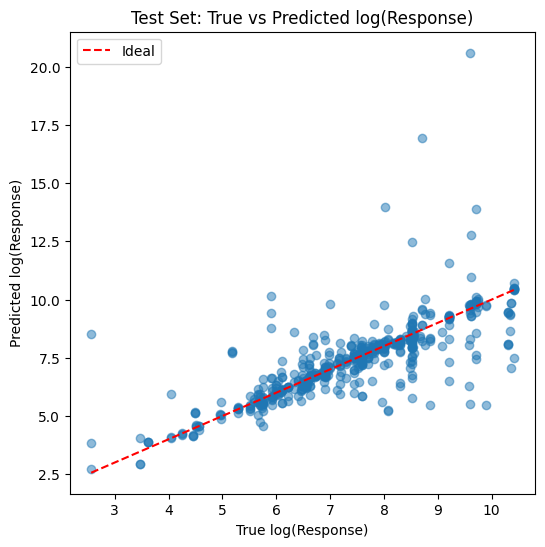

Test Set Mean Squared Error: 1.2079
Test Set R^2 Score: 0.4601


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Use the correct source for true values
y_true_test = test_output_df3_QQpos_copy['log_response'].values
y_pred_test = ChemNet_MLP_test_output_df3_QQpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_test = mean_squared_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"Test Set Mean Squared Error: {mse_test:.4f}")
print(f"Test Set R^2 Score: {r2_test:.4f}")


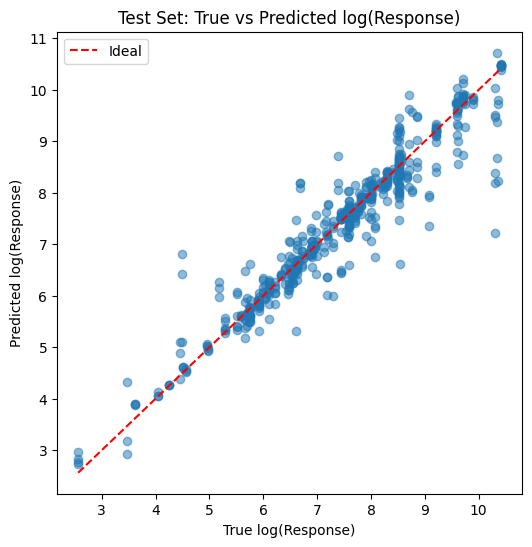

Train Set Mean Squared Error: 0.1993
Train Set R^2 Score: 0.9112


In [ ]:
# Use the correct source for true values
y_true_train = train_output_df3_QQpos_copy['log_response'].values
y_pred_train = ChemNet_MLP_train_output_df3_QQpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_train, y_pred_train, alpha=0.5)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_train = mean_squared_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
print(f"Train Set Mean Squared Error: {mse_train:.4f}")
print(f"Train Set R^2 Score: {r2_train:.4f}")

### MLP on the super test set

In [ ]:
print(super_test_output_df3_QQpos_withEPA.shape)
super_test_output_df3_QQpos_withEPA.head()

(86, 518)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,-0.028179,-0.003804,-0.048880,-0.033507,-0.206320,0.211676,-0.517948,-0.459876,-0.190006,-0.097550,...,-0.495393,-0.405189,-0.068908,0.404605,C#CCN(C)Cc1ccccc1,5.611823,0,1,0,0
1,-0.024357,-0.007619,-0.059876,-0.070616,-0.217324,0.216109,-0.504726,-0.456106,-0.189878,-0.061074,...,-0.525582,-0.433353,-0.058349,0.412030,C#CCN(C)Cc1ccccc1,5.611823,0,1,0,0
2,-0.030615,-0.005404,-0.050698,-0.041602,-0.205647,0.212722,-0.515107,-0.459397,-0.186581,-0.082477,...,-0.508410,-0.416671,-0.062223,0.405603,C#CCN(C)Cc1ccccc1,5.611823,0,1,0,0
3,-0.071203,0.020732,-0.218771,0.371120,-0.101973,0.080458,-0.082356,-0.290431,-0.123298,-0.208968,...,-0.107519,0.467029,0.136727,-0.100462,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,8.517193,0,0,1,0
4,-0.306513,-0.047177,0.021918,0.158992,-0.181577,0.004049,-0.050126,-0.194884,-0.033147,0.206950,...,-0.051797,0.208654,0.126238,-0.292947,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,8.517193,0,0,1,0


Training data shape: torch.Size([564, 512])
Super test set shape: (86, 512)
Number of embedding columns in super test set: 512
MLP model expects input size: 512
Super test set has: 512 features
Final super test set shape: (86, 512)


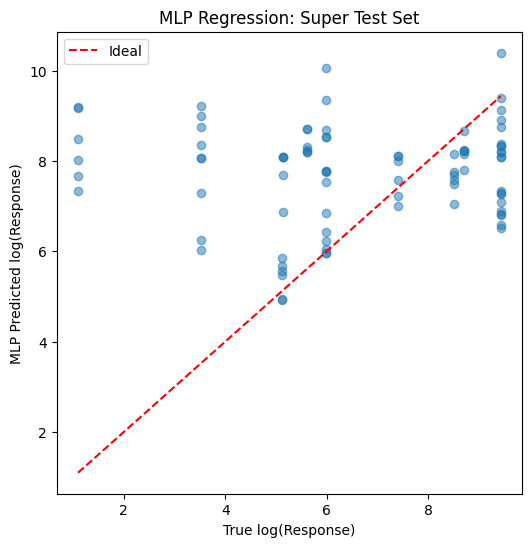

Super Test Set Mean Squared Error: 8.3526
Super Test Set R^2 Score: -0.3741


In [ ]:
# --- ChemNet MLP: Predict and evaluate on super test set (NO retraining) ---

# Prepare X for the super test set (ChemNet embeddings)
embedding_cols = [col for col in super_test_output_df3_QQpos_withEPA.columns if col.startswith('Embedding Float')]
X_super = super_test_output_df3_QQpos_withEPA[embedding_cols].values
y_super = super_test_output_df3_QQpos_withEPA['log_response'].values

# Debug information
print(f"Training data shape: {x_train.shape}")
print(f"Super test set shape: {X_super.shape}")
print(f"Number of embedding columns in super test set: {len(embedding_cols)}")
print(f"MLP model expects input size: {x_train.shape[1]}")
print(f"Super test set has: {X_super.shape[1]} features")

# Check if we need to adjust the feature size
if X_super.shape[1] != x_train.shape[1]:
    print(f"Shape mismatch! Need to adjust from {X_super.shape[1]} to {x_train.shape[1]} features")
    
    # Option 1: Truncate the super test set to match training data size
    if X_super.shape[1] > x_train.shape[1]:
        print("Truncating super test set to match training data size")
        X_super = X_super[:, :x_train.shape[1]]
    
    # Option 2: Pad the super test set if it's smaller (unlikely in this case)
    elif X_super.shape[1] < x_train.shape[1]:
        print("Padding super test set to match training data size")
        padding = np.zeros((X_super.shape[0], x_train.shape[1] - X_super.shape[1]))
        X_super = np.concatenate([X_super, padding], axis=1)

print(f"Final super test set shape: {X_super.shape}")

# Convert to tensor and move to device
x_super_tensor = torch.tensor(X_super, dtype=torch.float32).to(device)

# Predict with the already-trained MLP
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    y_pred_super = MLP_model_df3_QQpos(x_super_tensor).cpu().numpy().flatten()

# Visualization and metrics
plt.figure(figsize=(6,6))
plt.scatter(y_super, y_pred_super, alpha=0.5)
plt.plot([y_super.min(), y_super.max()], [y_super.min(), y_super.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('MLP Predicted log(Response)')
plt.title('MLP Regression: Super Test Set')
plt.legend()
plt.show()

mse_super = mean_squared_error(y_super, y_pred_super)
r2_super = r2_score(y_super, y_pred_super)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

### Random forest regressor

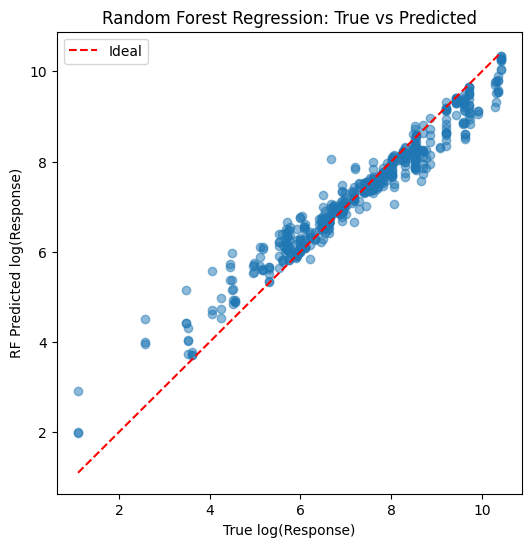

Random Forest Mean Squared Error: 0.1822
Random Forest R^2 Score: 0.9288


In [ ]:
# Prepare X and y for the Random Forest
X_rf = test_output_df3_QQpos_copy.iloc[:, :-4].select_dtypes(include=[float, int]).values
y_rf = test_output_df3_QQpos_copy['log_response'].values

# Train/test split (here, use all for both train and test for direct comparison, or split as needed)
# For demonstration, train and test on the same set
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)
y_pred_rf = rf_reg.predict(X_rf)

# Plotting
plt.figure(figsize=(6,6))
plt.scatter(y_rf, y_pred_rf, alpha=0.5)
plt.plot([y_rf.min(), y_rf.max()], [y_rf.min(), y_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Metrics
mse_rf = mean_squared_error(y_rf, y_pred_rf)
r2_rf = r2_score(y_rf, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Training QTOFpos

In [289]:
combined_output_df3_QTOFpos = pd.concat([train_output_df3_QTOFpos, test_output_df3_QTOFpos], ignore_index=True)
print(combined_output_df3_QTOFpos.shape)
combined_output_df3_QTOFpos.head()

(577, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,0.379461,-0.069426,-0.119688,0.393538,-0.049795,0.095896,-0.614914,-0.722117,-0.411202,-0.788390,...,-0.681943,-0.238988,0.296672,0.695732,0.583286,-0.352848,C=CCN(CC=C)C(=O)C(Cl)Cl,1989.75212,7.595765,0
1,0.340890,0.005029,0.001548,0.304833,-0.158407,0.061046,-0.384234,-0.766392,-0.567583,-0.373816,...,-0.111529,-0.054964,0.012219,0.643919,0.337343,-0.227243,C=CCN(CC=C)C(=O)C(Cl)Cl,1989.75212,7.595765,1
2,-0.033994,-0.006343,0.034954,0.164416,-0.101352,0.137025,-0.023140,-0.085074,-0.260835,0.194729,...,-0.178974,0.019778,-0.022675,-0.037834,-0.099378,-0.146447,CC(=O)C1=C(C)C(=C(C(=C1C)[N+]([O-])=O)C(C)(C)C...,10000.00000,9.210340,3
3,0.619211,0.013068,-0.251669,-0.148829,-0.375353,0.002842,0.581653,-0.231612,-0.189819,-0.522097,...,-0.798159,-0.156696,0.604363,0.409308,-0.695104,0.420394,CC(=O)C1=C(C)C(=C(C(=C1C)[N+]([O-])=O)C(C)(C)C...,10000.00000,9.210340,3
4,-0.261046,0.093281,0.335787,0.791997,-0.236496,0.280991,-0.395698,-0.078710,-0.005013,-0.742293,...,-0.654343,-0.078839,0.907555,0.567389,-0.340921,-0.474513,CC(=O)N(CC(O)CO)C1=C(I)C(C(=O)NCC(O)CO)=C(I)C(...,20000.00000,9.903488,4


In [290]:
# Generalize the syntax
dataset = combined_output_df3_QTOFpos

train_indices = []
test_indices = []

for smiles, group in dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = dataset.loc[train_indices].reset_index(drop=True)
test_data = dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
#train_data['index'] = train_data.index
#test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_output_df3_QTOFpos = train_data.copy()
test_output_df3_QTOFpos = test_data.copy()
val_data = test_output_df3_QTOFpos

# Make a copy
train_output_df3_QTOFpos_copy = train_data.copy()
test_output_df3_QQpos_copy = test_data.copy()

In [291]:
print(train_output_df3_QTOFpos.shape)
train_output_df3_QTOFpos.head()

(298, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,0.340890,0.005029,0.001548,0.304833,-0.158407,0.061046,-0.384234,-0.766392,-0.567583,-0.373816,...,-0.111529,-0.054964,0.012219,0.643919,0.337343,-0.227243,C=CCN(CC=C)C(=O)C(Cl)Cl,1989.75212,7.595765,1
1,0.379461,-0.069426,-0.119688,0.393538,-0.049795,0.095896,-0.614914,-0.722117,-0.411202,-0.788390,...,-0.681943,-0.238988,0.296672,0.695732,0.583286,-0.352848,C=CCN(CC=C)C(=O)C(Cl)Cl,1989.75212,7.595765,0
2,0.574114,0.017649,-0.263675,-0.115631,-0.328995,0.047900,0.585009,-0.296397,-0.197946,-0.547973,...,-0.831213,-0.173215,0.683469,0.347065,-0.711391,0.463653,CC(=O)C1=C(C)C(=C(C(=C1C)[N+]([O-])=O)C(C)(C)C...,10000.00000,9.210340,2
3,0.620724,0.012653,-0.258598,-0.147510,-0.372021,-0.001300,0.582509,-0.231830,-0.189107,-0.525947,...,-0.802329,-0.158806,0.606043,0.412317,-0.691800,0.420208,CC(=O)C1=C(C)C(=C(C(=C1C)[N+]([O-])=O)C(C)(C)C...,10000.00000,9.210340,2
4,0.096869,0.081868,-0.353867,-0.129598,-0.348815,0.262172,0.115561,-0.313292,-0.186397,0.012329,...,-0.458573,0.051641,-0.136207,0.397661,0.013838,0.038733,CC(=O)N(CC(O)CO)C1=C(I)C(C(=O)NCC(O)CO)=C(I)C(...,20000.00000,9.903488,5


In [292]:
# MLP training
device = f.set_up_gpu()

# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox_spec(
    train_output_df3_QTOFpos, device, start_idx=2, stop_idx=-0)
del train_output_df3_QTOFpos

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox_spec(
    test_output_df3_QTOFpos, device, start_idx=2, stop_idx=-0)
del test_output_df3_QTOFpos


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21468.0 MB
  Memory Used: 2748.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [293]:
train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_QTOFpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_QTOFpos = train_model_MLP(
    model=toxMLP_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Epoch [1/100]
   Training loss: 56.69613952636719
   Validation loss: 27.708160400390625
Epoch [2/100]
   Training loss: 55.79819107055664
   Validation loss: 26.35438346862793
Epoch [3/100]
   Training loss: 55.50911407470703
   Validation loss: 26.84871482849121
Epoch [4/100]
   Training loss: 54.67387008666992
   Validation loss: 25.90984535217285
Epoch [5/100]
   Training loss: 54.582621002197264
   Validation loss: 27.58771324157715
Epoch [6/100]
   Training loss: 53.01600646972656
   Validation loss: 25.68031120300293
Epoch [7/100]
   Training loss: 51.33751907348633
   Validation loss: 25.036958694458008
Epoch [8/100]
   Training loss: 48.780207824707034
   Validation loss: 24.042016983032227
Epoch [9/100]
   Training loss: 44.872789001464845
   Validation loss: 22.25484848022461
Epoch [10/100]
   Training loss: 38.54246635437012
   Validation loss: 17.446033477783203
Epoch [11/100]
   Training loss: 30.98063507080078
   Validation loss: 14.42216968536377
Epoch [12/100]
   Train

### MLP Evaluation QTOFpos

In [ ]:
# Excecution
MLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    ChemNet_MLP_test_output_df3_QTOFpos = toxMLP_df3_QTOFpos(x_val) 

# Excecution
MLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    ChemNet_MLP_train_output_df3_QTOFpos = toxMLP_df3_QTOFpos(x_train)


In [ ]:
# Use the correct source for true values
y_true_test = test_output_df3_QTOFpos_copy['log_response'].values
y_pred_test = ChemNet_MLP_test_output_df3_QTOFpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_test = mean_squared_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"Test Set Mean Squared Error: {mse_test:.4f}")
print(f"Test Set R^2 Score: {r2_test:.4f}")


In [ ]:
# Use the correct source for true values
y_true_train = train_output_df3_QTOFpos_copy['log_response'].values
y_pred_train = ChemNet_MLP_train_output_df3_QTOFpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_train, y_pred_train, alpha=0.5)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_train = mean_squared_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
print(f"Train Set Mean Squared Error: {mse_train:.4f}")
print(f"Train Set R^2 Score: {r2_train:.4f}")

### MLP on super test set QTOFpos

In [ ]:
# --- ChemNet MLP: Predict and evaluate on super test set (NO retraining) ---

# Prepare X for the super test set (ChemNet embeddings)
embedding_cols = [col for col in super_test_output_df3_QTOFpos_withEPA.columns if col.startswith('Embedding Float')]
X_super = super_test_output_df3_QTOFpos_withEPA[embedding_cols].values
y_super = super_test_output_df3_QTOFpos_withEPA['log_response'].values

# Debug information
print(f"Training data shape: {x_train.shape}")
print(f"Super test set shape: {X_super.shape}")
print(f"Number of embedding columns in super test set: {len(embedding_cols)}")
print(f"MLP model expects input size: {x_train.shape[1]}")
print(f"Super test set has: {X_super.shape[1]} features")

# Check if we need to adjust the feature size
if X_super.shape[1] != x_train.shape[1]:
    print(f"Shape mismatch! Need to adjust from {X_super.shape[1]} to {x_train.shape[1]} features")
    
    # Option 1: Truncate the super test set to match training data size
    if X_super.shape[1] > x_train.shape[1]:
        print("Truncating super test set to match training data size")
        X_super = X_super[:, :x_train.shape[1]]
    
    # Option 2: Pad the super test set if it's smaller (unlikely in this case)
    elif X_super.shape[1] < x_train.shape[1]:
        print("Padding super test set to match training data size")
        padding = np.zeros((X_super.shape[0], x_train.shape[1] - X_super.shape[1]))
        X_super = np.concatenate([X_super, padding], axis=1)

print(f"Final super test set shape: {X_super.shape}")

# Convert to tensor and move to device
x_super_tensor = torch.tensor(X_super, dtype=torch.float32).to(device)

# Predict with the already-trained MLP
MLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    y_pred_super = MLP_model_df3_QTOFpos(x_super_tensor).cpu().numpy().flatten()

# Visualization and metrics
plt.figure(figsize=(6,6))
plt.scatter(y_super, y_pred_super, alpha=0.5)
plt.plot([y_super.min(), y_super.max()], [y_super.min(), y_super.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('MLP Predicted log(Response)')
plt.title('MLP Regression: Super Test Set')
plt.legend()
plt.show()

mse_super = mean_squared_error(y_super, y_pred_super)
r2_super = r2_score(y_super, y_pred_super)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

### Random forest regressor QTOFpos

In [ ]:
# Prepare X and y for the Random Forest
X_rf = test_output_df3_QTOFpos_copy.iloc[:, :-4].select_dtypes(include=[float, int]).values
y_rf = test_output_df3_QTOFpos_copy['log_response'].values

# Train/test split (here, use all for both train and test for direct comparison, or split as needed)
# For demonstration, train and test on the same set
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)
y_pred_rf = rf_reg.predict(X_rf)

# Plotting
plt.figure(figsize=(6,6))
plt.scatter(y_rf, y_pred_rf, alpha=0.5)
plt.plot([y_rf.min(), y_rf.max()], [y_rf.min(), y_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Metrics
mse_rf = mean_squared_error(y_rf, y_pred_rf)
r2_rf = r2_score(y_rf, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

# Spectra --> ChemNet AND Toxicity Conditional Encoder

### Architecture

In [ ]:
batch_size = 64
epochs=500
lr=0.0001
criterion1=nn.MSELoss()
criterion2=nn.MSELoss()
output_size = 513
num_layers = 8

#%%
# Encoder architecture (With Validation Set)
class Cond_Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_condenc(model, train_data, val_data, epochs, learning_rate, criterion1, criterion2, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_combined = model(batch) # Take the first 512 for criterion 1 and the last for criterion 2, look up to make sure i only apply the loss to the subset of the model
            
            # Embedding Loss
            batch_predicted_embeddings = batch_predicted_combined[:, :512] # First 512 columns
            loss1 = criterion1(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss)
            # Response Loss
            batch_predicted_log_tox = batch_predicted_combined[:, 512:] # Last column
            loss2 = criterion2(batch_predicted_log_tox, true_log_tox) # loss2 (toxicity loss)
            
            total_loss = loss1 + loss2
            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():  # Condense this as we did above for symmetry tho not needed without loss.backward command
            for val_batch, val_true_embeddings, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted = model(val_batch)
                val_batch_predicted_embeddings = val_batch_predicted[:, :512]

                val_loss = criterion1(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss1.item()

                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_tox.to(device)

                val_batch_predicted_tox = val_batch_predicted[:, 512:]

                val_loss = criterion2(val_batch_predicted_tox, val_true_tox)
                val_loss += loss2.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training and Testing set construction

In [ ]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

In [ ]:
# Add the 'Response' and 'log_response' columns to df3_QQpos_spectra
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

In [ ]:
df3_QQpos_spectra.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,672,673,674,675,676,677,678,679,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823


In [ ]:
# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data_df3_QQpos = add_response_and_log_response(train_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')
test_data_df3_QQpos = add_response_and_log_response(test_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')

# Make a copy
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 683)
(579, 683)


In [ ]:
test_data_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,673,674,675,676,677,678,679,index,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,273.642508,5.611823
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5000.000000,8.517193
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5000.000000,8.517193


In [ ]:
def create_dataset_tensors_emb_tox(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true embeddings, true toxicity values, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, log_tox_tensor, spectra_tensor, spectra_indices_tensor 

In [ ]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_emb, y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_emb_tox(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_emb, y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_emb_tox(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_emb, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_emb, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
cond_encoder_df3_QQpos = Cond_Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
cond_encoder_model_df3_QQpos = train_model_condenc(
    model=cond_encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion1=criterion1,
    criterion2=criterion2,
    device=device
)

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22149.0 MB
  Memory Used: 2067.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 55.069632339477536
   Validation loss: 9.881281852722168
Epoch [2/500]
   Training loss: 31.600512504577637
   Validation loss: 1.2119745016098022
Epoch [3/500]
   Training loss: 9.575532388687133
   Validation loss: 1.275824785232544
Epoch [4/500]
   Training loss: 7.0069256782531735
   Validation loss: 0.7560495734214783
Epoch [5/500]
   Training loss: 4.616932129859924
   Validation loss: 0.532633900642395
Epoch [6/500]
   Training loss: 3.460732269287109
   Validation loss: 0.7520135045051575
Epoch [7/500]
   Training loss: 2.7205834865570067
   Validation loss: 0.6736278533935547
Epoch [8/500]
   Training loss: 2.230940508842468
   Validation loss: 0.6248937845230103
Epoch [9/500]
   Training loss: 1.8702359437942504
   Vali